# Notebook 03: Classification Model

**Student Name:** Denz'l Chapman

**Dataset:** Industry Market Cap Dataset

**Original Target Variable:** Marketcap

**Binned Target Variable:** Small Cap, Mid Cap, Large Cap

**Checkpoint 4 Due:** Feb 22

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before the checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll be asked to interpret results, justify decisions, and explain your reasoning. **These written reflections are a critical part of your grade.**

Your binning justification, model selection reasoning, and analysis of the confusion matrix demonstrate your understanding. These reflections are what employers look for—the ability to communicate technical decisions clearly.

---

## Setup

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Processed Data

In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (1490, 25)


,marketcap,revenue,earnings,operating-margin,total-assets,total-liabilities,total-debt,net-assets,pe-ratio,ps-ratio,...,Industry_Oil&Gas,Industry_Pharmaceuticals,Industry_Real Estate,Industry_Retail,Industry_Technology,Country_India,Country_Japan,Country_Other,Country_UK,Country_USA
0,7.584265,6.355726,3.731220,-0.0115,6.270705,5.789868,4.917130,5.312565,96.50,3.4200,...,0,0,0,0,1,0,0,0,0,1
1,4.185860,5.294912,1.968510,0.0255,4.862908,4.309993,3.457263,4.024458,16.10,0.3255,...,0,0,0,0,1,0,0,1,0,0
2,3.772761,5.033570,1.776646,0.0255,4.467975,3.824721,2.374906,3.745968,13.70,0.2839,...,0,0,0,0,1,0,0,0,0,0
3,5.144117,4.140751,2.271094,0.0308,4.914418,4.732860,4.109726,3.161670,24.40,2.7600,...,0,0,0,0,1,0,0,0,0,1
4,3.114848,4.104955,1.427916,0.0487,4.162159,3.505257,2.509599,3.463233,7.18,0.3597,...,0,0,0,0,1,0,1,0,0,0


In [3]:
# Converting marketcap back to a decimal in the billions for binning
# Does this mean i need to convert my features back to thier original form as well?

df['marketcap'] = np.expm1(df['marketcap'])

In [4]:
# Viewing marketcap values to see if coreectly converted back to billons
print(df['marketcap'].head())

0    1966.00
1      64.75
2      42.50
3     170.42
4      21.53
Name: marketcap, dtype: float64


In [5]:
# Define your original target variable
ORIGINAL_TARGET = 'marketcap'  # <-- UPDATE THIS

print(f"Original Target: {ORIGINAL_TARGET}")
print(f"\nTarget statistics:")
print(df[ORIGINAL_TARGET].describe())

Original Target: marketcap

Target statistics:
count    1490.000000
mean       34.184450
std       170.672624
min         0.000070
25%         1.787500
50%         5.795000
75%        18.832500
max      3179.000000
Name: marketcap, dtype: float64


## Section 2: Create Binned Target

Convert your regression target into classification categories.

### 2.1 Binning Strategy Justification

**Your approved binning strategy:**

- Small Cap: $250Million - $2Billion
- Mid Cap: $2Billion - $10Billion
- Large Cap: $10Billion +



**Why this makes sense for your problem:**
My Original Binning strategy included 5 bins, instead i chose to simplify it to 3 bins to help boost model performance. I did not have adequate data to represent both Micro Cap and Mega Cap companies. Both classifications would have had less that 4% of data to represent those classifications. 
This binning strategy makes sense for my TARGET marketcap because this is how publicly traded companies are categorized in the stock market. 

In [6]:
# View the distribution before binning
print("Target distribution:")
print(f"Min: {df[ORIGINAL_TARGET].min():.2f}")
print(f"25th percentile: {df[ORIGINAL_TARGET].quantile(0.25):.2f}")
print(f"Median: {df[ORIGINAL_TARGET].median():.2f}")
print(f"75th percentile: {df[ORIGINAL_TARGET].quantile(0.75):.2f}")
print(f"Max: {df[ORIGINAL_TARGET].max():.2f}")

Target distribution:
Min: 0.00
25th percentile: 1.79
Median: 5.79
75th percentile: 18.83
Max: 3179.00


In [7]:
# TODO: Create your binned target using YOUR approved binning strategy
#
# Steps:
# 1. Define your bin edges (e.g., bins = [min-1, threshold1, threshold2, max+1])
# 2. Define your category labels (e.g., labels = ['Low', 'Medium', 'High'])
# 3. Use pd.cut() to create the binned column
#
# Example:
# bins = [df[ORIGINAL_TARGET].min()-1, 50000, 100000, df[ORIGINAL_TARGET].max()+1]
# labels = ['Low', 'Medium', 'High']
# df['target_category'] = pd.cut(df[ORIGINAL_TARGET], bins=bins, labels=labels)

# YOUR CODE HERE:                                                               # Eliminated MicroCap Bin to see if it would boost model performance
bins = [ -np.inf , 2.0, 10.0, np.inf]                                   # Converted back to Billions, first Bin $2 Billion = 2.0
labels = [ 'Small Cap', 'Mid Cap', 'Large Cap']                              # Second Bin $10Billion = 10.0
                                                                                    # Third Bin $200 Billion = 200.0
df['target_category'] = pd.cut(df[ORIGINAL_TARGET], bins=bins, labels=labels)   

print("Binned target distribution:")
print(df['target_category'].value_counts())

Binned target distribution:
target_category
Large Cap    566
Mid Cap      529
Small Cap    395
Name: count, dtype: int64


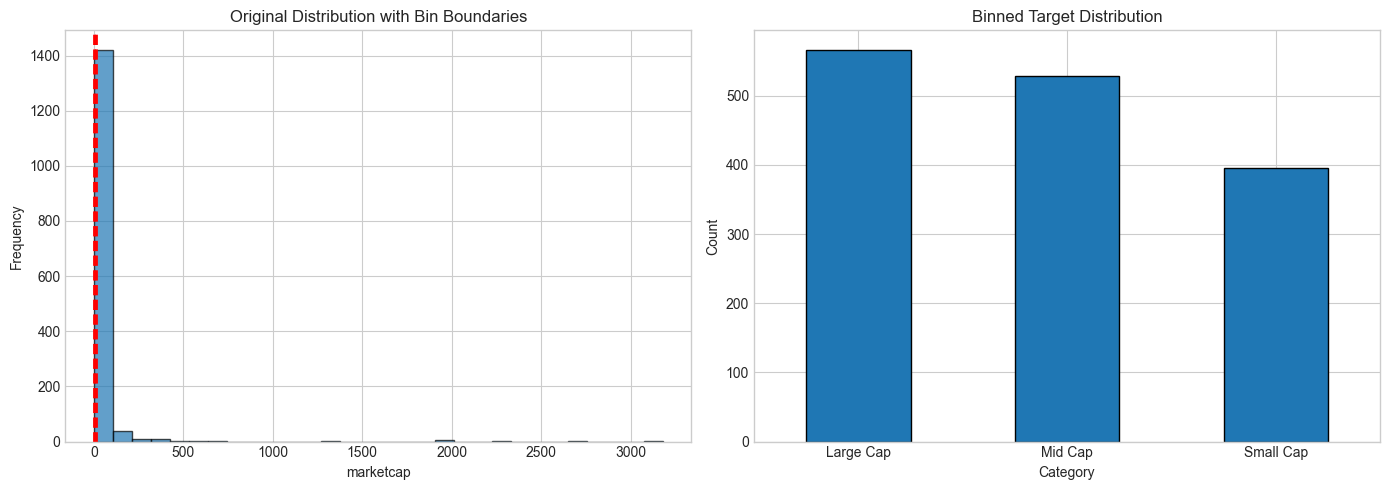

In [8]:
# Visualize the binned distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution with bin lines
axes[0].hist(df[ORIGINAL_TARGET], bins=30, edgecolor='black', alpha=0.7)
for edge in bins[1:-1]:  # Skip first and last (min/max)
    axes[0].axvline(edge, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel(ORIGINAL_TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution with Bin Boundaries')

# Binned category counts
df['target_category'].value_counts().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Binned Target Distribution')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 2.2 Check Class Balance

*Is your binned target reasonably balanced?*

In [9]:
# Check class balance
class_counts = df['target_category'].value_counts()
class_percentages = df['target_category'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
Large Cap: 566 (38.0%)
Mid Cap: 529 (35.5%)
Small Cap: 395 (26.5%)

Class balance looks reasonable!


## Section 3: Feature Consistency Check

**Important:** For consistency, you should use the same features for classification as you did for regression. This makes your app simpler (users enter the same inputs for both models) and allows for fair comparison.

If you decide to use different features, provide a strong justification below.

In [10]:
# Load the features you selected in the regression notebook
try:
    regression_features = joblib.load('../models/regression_features.pkl')
    print("Features from Regression Model:")
    print(regression_features)
    print(f"\nNumber of regression features: {len(regression_features)}")
except FileNotFoundError:
    print("Warning: regression_features.pkl not found!")
    print("Make sure you've completed Notebook 02 and saved your regression model first.")
    regression_features = None

Features from Regression Model:
['total-assets', 'earnings', 'total-debt', 'return-on-assets', 'return-on-equity', 'debt-to-equity', 'revenue', 'net-assets', 'Industry_Pharmaceuticals', 'Industry_Technology', 'Industry_Real Estate', 'Industry_Food', 'Industry_Oil&Gas', 'Industry_Insurance', 'Industry_Retail']

Number of regression features: 15


### Feature Selection Decision

**Will you use the same features as your regression model?**

- Yes, I will be using the same features as i did for my Regression Models. 

In [11]:
# DECIDE: Use regression features or define new ones?

# Option A: Use the same features as regression (RECOMMENDED)
if regression_features is not None:
    SELECTED_FEATURES = regression_features
    print("Using same features as regression model.")
else:
    # Option B: Define your own features (if regression not done yet)
    SELECTED_FEATURES = [
        # 'feature1',
        # 'feature2',
        # 'feature3',
        # etc.
    ]
    print("Defining features manually.")

print(f"\nSelected features for classification ({len(SELECTED_FEATURES)}):")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f"  {i}. {f}")

Using same features as regression model.

Selected features for classification (15):
  1. total-assets
  2. earnings
  3. total-debt
  4. return-on-assets
  5. return-on-equity
  6. debt-to-equity
  7. revenue
  8. net-assets
  9. Industry_Pharmaceuticals
  10. Industry_Technology
  11. Industry_Real Estate
  12. Industry_Food
  13. Industry_Oil&Gas
  14. Industry_Insurance
  15. Industry_Retail


## Section 4: Prepare Features and Target

In [12]:
# Create feature matrix using SELECTED features
X = df[SELECTED_FEATURES].copy()
y = df['target_category']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (1490, 15)
Target shape: (1490,)

Features used: ['total-assets', 'earnings', 'total-debt', 'return-on-assets', 'return-on-equity', 'debt-to-equity', 'revenue', 'net-assets', 'Industry_Pharmaceuticals', 'Industry_Technology', 'Industry_Real Estate', 'Industry_Food', 'Industry_Oil&Gas', 'Industry_Insurance', 'Industry_Retail']

Target classes: ['Large Cap', 'Mid Cap', 'Small Cap']


### 4.1 Label Encoding

Many sklearn models require numeric targets. Use LabelEncoder to convert category names to numbers.

In [13]:
# TODO: Encode your target labels to numbers using LabelEncoder
#
# Steps:
# 1. Create a LabelEncoder instance
# 2. Fit and transform y to create y_encoded
#
# Hint: label_encoder.fit_transform(y)

# YOUR CODE HERE:

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [14]:
# Verify encoding (run this to check)
print("Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Label encoding:
Large Cap -> 0
Mid Cap -> 1
Small Cap -> 2


## Section 5: Train-Test Split

For classification, we use **stratified** splitting to ensure each class is proportionally represented in both train and test sets.

In [15]:
# TODO: Split your data with stratification
#
# Requirements:
# - 80/20 split (test_size=0.2)
# - random_state=42 for reproducibility
# - stratify=y_encoded (THIS IS THE KEY DIFFERENCE FROM REGRESSION!)
#   This ensures each class is proportionally represented in train/test
#
# Store in: X_train, X_test, y_train, y_test

# YOUR CODE HERE:

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [16]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]}: {c} ({c/len(y_train)*100:.1f}%)")

Training set: 1192 samples
Test set: 298 samples

Training class distribution:
  Large Cap: 453 (38.0%)
  Mid Cap: 423 (35.5%)
  Small Cap: 316 (26.5%)


## Section 6: Feature Scaling

In [17]:
# TODO: Scale your features using StandardScaler
#
# Same as regression:
# 1. Create StandardScaler instance
# 2. fit_transform on X_train
# 3. transform (only!) on X_test
#
# Store in: X_train_scaled, X_test_scaled

# YOUR CODE HERE:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Convert to DataFrame (helpful for later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 15 features.


## Section 7: Baseline Model

In [19]:
# This helper function evaluates any classifier - you'll use it throughout
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    """Train classifier and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision (weighted)': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall (weighted)': recall_score(y_test, y_test_pred, average='weighted'),
        'F1 (weighted)': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    return results, model, y_test_pred

In [20]:
# TODO: Create and evaluate a baseline Logistic Regression model
#
# Create LogisticRegression(random_state=42, max_iter=1000)
# Use evaluate_classifier() to train and evaluate

# YOUR CODE HERE:
# baseline_model = ...
# baseline_results, baseline_trained, baseline_preds = evaluate_classifier(...)

baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_results, baseline_trained, baseline_preds = evaluate_classifier(baseline_model, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression (Baseline)" )

In [21]:
# Display baseline results
print("=" * 50)
print("BASELINE MODEL: Logistic Regression")
print("=" * 50)
print(f"Train Accuracy: {baseline_results['Train Accuracy']:.4f}")
print(f"Test Accuracy:  {baseline_results['Test Accuracy']:.4f}")
print(f"F1 Score:       {baseline_results['F1 (weighted)']:.4f}")

BASELINE MODEL: Logistic Regression
Train Accuracy: 0.7299
Test Accuracy:  0.7517
F1 Score:       0.7509


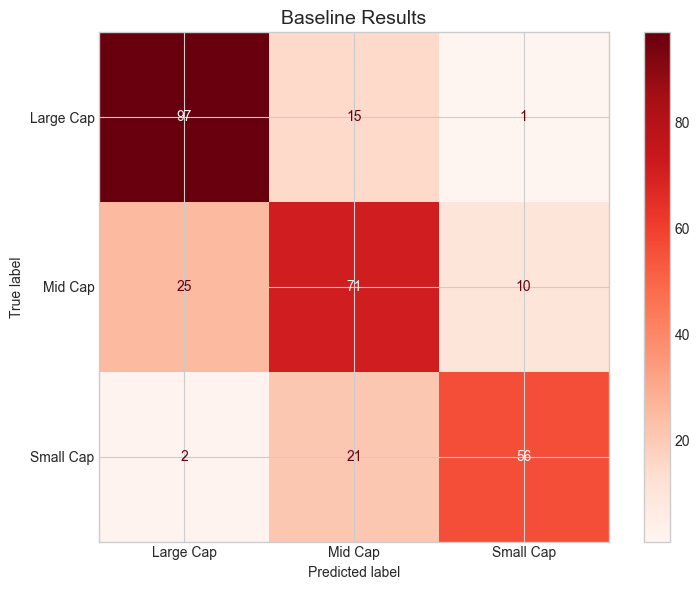

In [22]:
# TODO: Create and display the confusion matrix for baseline
#
# Steps:
# 1. Use confusion_matrix(y_test, baseline_preds) to create the matrix
# 2. Use ConfusionMatrixDisplay to visualize it
#
# Hint: ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# YOUR CODE HERE:
plt.figure(figsize=(8,6))

cm = confusion_matrix(y_test, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap = 'Reds', ax=plt.gca())

plt.title('Baseline Results', fontsize=14)
plt.tight_layout()
plt.show()

### Understanding the Confusion Matrix

The confusion matrix shows where your model gets predictions right and wrong:

- **Diagonal cells (top-left to bottom-right):** Correct predictions
- **Off-diagonal cells:** Misclassifications
- **Row:** What the actual class was
- **Column:** What the model predicted

**How to read it:** 
- If a row has many values spread across columns, that class is often confused with others
- If a column has many values from different rows, the model is predicting that class too often

**Example interpretation:**
- "20 Low samples were correctly predicted as Low"
- "5 Medium samples were incorrectly predicted as High"

### Baseline Interpretation

*Analyze your baseline results:*

**Questions to answer:**
- How well does the baseline perform?
- Which classes are easiest/hardest to predict (look at the diagonal)?
- Where does the model get confused (look at off-diagonal cells)?
- Is there overfitting (train vs test accuracy gap)?

**Your interpretation:**

The baseline logistic regression model had a training accuracy of 0.7299 and testing accuracy of 0.7517. The test and train accuracy  of the baseline model would suggest there is no evidence of overfitting and considering dealing with intiricate stock market data i believe the model is performing reasonably well given the results. The model seems to be getting confued right where the boundaries between Marketcap beging to change, for example when predicting Mid cap the model had 21 instances where it predicted Mid Cap and it was actually small cap and 15 instances it predicted Mid Cap when it was actually Large cap.

## Section 8: Cross-Validation

Cross-validation gives us a more robust estimate of model performance by training on different portions of the data.

In [23]:
# Cross-validation for key models
print("5-Fold Cross-Validation Results")
print("=" * 50)

models_to_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

cv_results = []
for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std': scores.std()
    })
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)
cv_df

5-Fold Cross-Validation Results
Logistic Regression: 0.7156 (+/- 0.0628)
Random Forest: 0.7382 (+/- 0.0554)
Gradient Boosting: 0.7290 (+/- 0.0356)


,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.715601,0.031399
1,Random Forest,0.738237,0.027697
2,Gradient Boosting,0.729018,0.017821


### Cross-Validation Interpretation

*What does the cross-validation tell you?*

- Which model is most consistent (lowest std)?
- Does the ranking change from the single train/test split?

**Your interpretation:**

The cross validation tells me that the model with the most consistency is Gradient Boosting which has a CV Std of 0.017821. This result tlls me that this model has good stability and performs the most concistently with different data splits. The ranking actually did not change from single train_test_split.

## Section 9: Model Iteration

In [24]:
# Store all results
all_results = [baseline_results]

# Dictionary to store trained models
trained_models = {
    'Logistic Regression (Baseline)': baseline_trained
}

### Model 2: Decision Tree

In [25]:
# TODO: Create and evaluate a Decision Tree classifier
#
# Create DecisionTreeClassifier(max_depth=10, random_state=42)
# Use evaluate_classifier() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_results, dt_trained, dt_preds = evaluate_classifier(dt_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Decision Tree Model')
all_results.append(dt_results)
trained_models['Decision Tree Model'] = dt_trained

# Print results
print(f"Decision Tree - Test Accuracy: {dt_results['Test Accuracy']:.4f}, F1: {dt_results['F1 (weighted)']:.4f}")

Decision Tree - Test Accuracy: 0.6544, F1: 0.6548


### Model 3: Random Forest

In [26]:
# TODO: Create and evaluate a Random Forest classifier
#
# Create RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
# Use evaluate_classifier()
# Add to all_results and trained_models

# YOUR CODE HERE:

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_results, rf_trained, rf_preds = evaluate_classifier(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Random Forest Model')
all_results.append(rf_results)
trained_models['Random Forest Model'] = rf_trained

# Print results
print(f"Random Forest - Test Accuracy: {rf_results['Test Accuracy']:.4f}, F1: {rf_results['F1 (weighted)']:.4f}")

Random Forest - Test Accuracy: 0.7450, F1: 0.7441


### Model 4: K-Nearest Neighbors

In [27]:
# TODO: Create and evaluate a KNN classifier
#
# Create KNeighborsClassifier(n_neighbors=5)
# Use evaluate_classifier()
# Add to all_results and trained_models

# YOUR CODE HERE:

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results, knn_trained, knn_preds = evaluate_classifier(knn_model, X_train_scaled, X_test_scaled, y_train, y_test, 'K-Nearest Neighbors')
all_results.append(knn_results)
trained_models['K-Nearest Neighbors'] = knn_trained


# Print results
print(f"KNN - Test Accuracy: {knn_results['Test Accuracy']:.4f}, F1: {knn_results['F1 (weighted)']:.4f}")

KNN - Test Accuracy: 0.7282, F1: 0.7268


### Model 5: Gradient Boosting

In [28]:
# TODO: Create and evaluate a Gradient Boosting classifier
#
# Create GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
# Use evaluate_classifier()
# Add to all_results and trained_models

# YOUR CODE HERE:

gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_results, gb_trained, gb_preds = evaluate_classifier(gb_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Gradient Boosting')
all_results.append(gb_results)
trained_models['Gradient Boosting'] = gb_trained

# Print results
print(f"Gradient Boosting - Test Accuracy: {gb_results['Test Accuracy']:.4f}, F1: {gb_results['F1 (weighted)']:.4f}")

Gradient Boosting - Test Accuracy: 0.7450, F1: 0.7426


### Add Your Own Model (Optional)

Try a different model or different hyperparameters!

In [29]:
# YOUR ADDITIONAL MODEL HERE:
# Try SVC, different hyperparameters, or another classifier

svc_model = SVC(kernel='rbf', C=1.0, gamma="scale", class_weight='balanced', random_state=42)
svc_results, svc_trained, svc_preds = evaluate_classifier(svc_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Support Vector Classifier')
all_results.append(svc_results)
trained_models['Support Vector Classifier'] = svc_trained

# Print Results
print(f"Support Vector Classifier - Test Accuracy: {svc_results['Test Accuracy']:.4f}, F1: {svc_results['F1 (weighted)']:.4f}")

Support Vector Classifier - Test Accuracy: 0.7483, F1: 0.7488


## Section 10: Model Comparison

In [30]:
# Create comparison DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("Model Comparison:")
results_df

Model Comparison:


,Model,Train Accuracy,Test Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Logistic Regression (Baseline),0.7299,0.7517,0.7542,0.7517,0.7509
5,Support Vector Classifier,0.7500,0.7483,0.7494,0.7483,0.7488
2,Random Forest Model,0.9639,0.7450,0.7437,0.7450,0.7441
4,Gradient Boosting,0.9992,0.7450,0.7419,0.7450,0.7426
3,K-Nearest Neighbors,0.7936,0.7282,0.7279,0.7282,0.7268
1,Decision Tree Model,0.9379,0.6544,0.6654,0.6544,0.6548


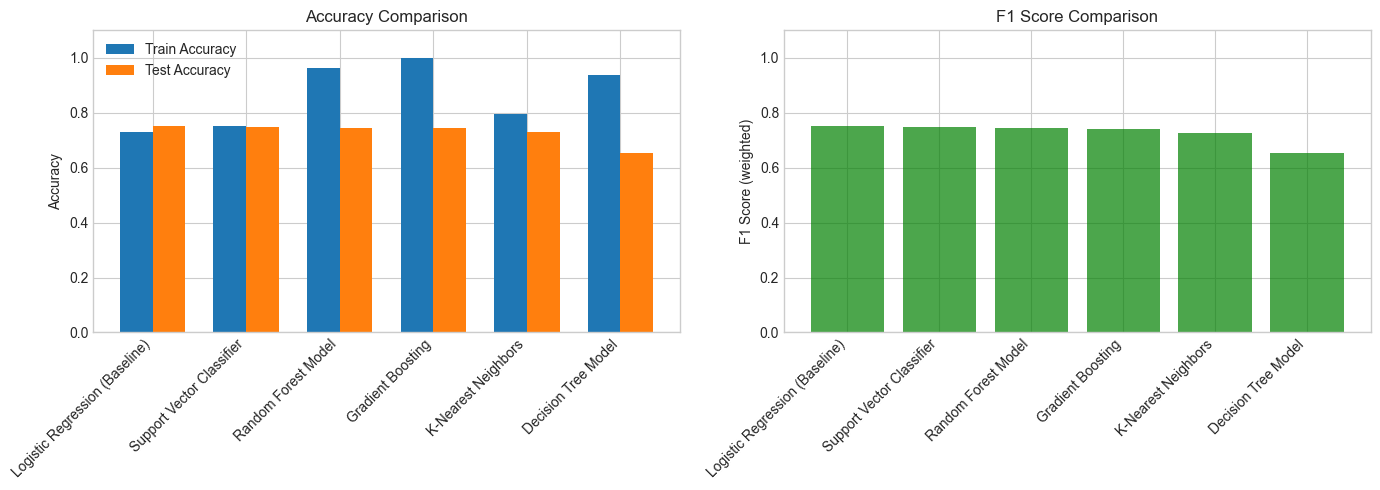

In [31]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['Model']
x = np.arange(len(models))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy')
axes[0].bar(x + width/2, results_df['Test Accuracy'], width, label='Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# F1 Score comparison
axes[1].bar(x, results_df['F1 (weighted)'], color='green', alpha=0.7)
axes[1].set_ylabel('F1 Score (weighted)')
axes[1].set_title('F1 Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## Section 11: Best Model Selection

In [32]:
# Identify best model (by test accuracy)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")
print(f"F1 Score: {results_df.iloc[0]['F1 (weighted)']:.4f}")

Best Model: Logistic Regression (Baseline)
Test Accuracy: 0.7517
F1 Score: 0.7509


### Best Model Justification

*Explain why you chose this model:*

**Questions to consider:**
- Why this model over others?
- Is there significant overfitting?
- How does it compare to baseline?
- Which metrics did you prioritize and why?

**Your justification:**

After analyzing the model comparisons, Logistic Regression stands out as the best performing model because it had the highest testing score with a 0.7517 tesing accuracy. Although it was not the most consistent when comparing it in the 5 Fold cross validation, it still stands out with the highest F1 score out of the other models. The ensemble methods tended to overfit and meorize the training data while scoring poorly on the testing sets. Logistic Regression on the other hand seems to make better generalizations and be the most stable when exposed to new data. The metrics i prioritized are the F1 score, test accuracy, and the cv std. these metrics are important to my data because the F1 score tells me that the model has the best balance between precision and recall out of all the models. Testing accuracy because although Logistic Regression had the highest testing accuracy it also had the smallest difference between testing and training which tells me that overfitting is not occuring. Lastly, the cv std is important because it shows that the logistic regression model has a high stability in maintaining performance when exposed to new data.

## Section 12: Best Model Analysis

In [33]:
# Get predictions from best model
y_pred = best_model.predict(X_test_scaled)

# Detailed classification report
print("Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

   Large Cap       0.78      0.86      0.82       113
     Mid Cap       0.66      0.67      0.67       106
   Small Cap       0.84      0.71      0.77        79

    accuracy                           0.75       298
   macro avg       0.76      0.75      0.75       298
weighted avg       0.75      0.75      0.75       298



### Understanding the Classification Report

The classification report shows per-class metrics:

- **Precision:** Of all predictions for this class, what % were correct?
  - High precision = Few false positives
  - Example: "When the model predicts 'High', it's correct 85% of the time"

- **Recall:** Of all actual instances of this class, what % did we find?
  - High recall = Few false negatives
  - Example: "We correctly identified 90% of all actual 'High' cases"

- **F1-Score:** Harmonic mean of precision and recall (balanced measure)
  - Good when you need both precision and recall

- **Support:** Number of actual occurrences of each class in the test set

<Figure size 800x600 with 0 Axes>

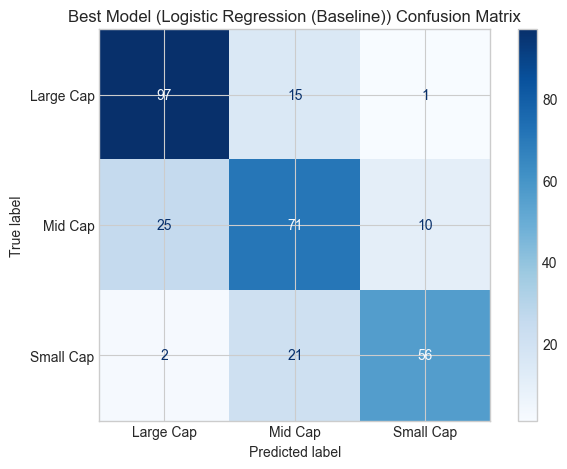

In [34]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title(f'Best Model ({best_model_name}) Confusion Matrix')
plt.tight_layout()
plt.show()

### Detailed Confusion Matrix Analysis

*Analyze the confusion matrix carefully:*

**For each class, describe:**
1. How many correct predictions (diagonal)?
2. What are the most common misclassifications?
3. Does the confusion make sense for your problem?

**Your analysis:**

My logistic regression model correctly predicted Large Cap in 97 instances, coreectly predicted Mid Cap in 71 instances, and correctly predicted Small Cap in 56 instances. The most common misclassifications tend to be Mid Cap, where the model predicted Large cap when it was actually Mid Cap or predicted Mid Cap when it was actually Small Cap. This confusion makes sense for my stock market data because it seems like the model is getting confused around the boundary thresholds. Trying to predict a companies marketcap based off the fundamentals alone is extremely dificult, the model may be getting hung up around the thresholds because a company valued around $2Billion could fall between the Small to Mid cap classification. 

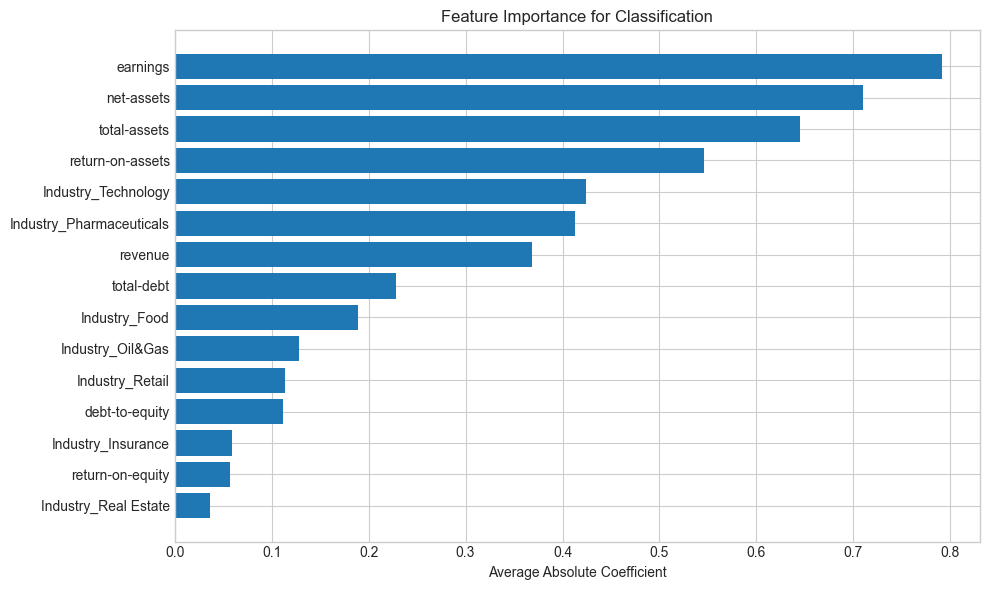

In [35]:
# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 most important features:")
    for i, row in importance.tail(5).iloc[::-1].iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
        
elif hasattr(best_model, 'coef_'):
    # For multi-class, coef_ has shape (n_classes, n_features)
    coef = best_model.coef_
    if len(coef.shape) > 1:
        # Average absolute importance across classes
        importance_vals = np.abs(coef).mean(axis=0)
    else:
        importance_vals = np.abs(coef)
    
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance_vals
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Average Absolute Coefficient')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()

## Section 13: Model Iteration Reflection

*Reflect on your modeling process:*

**1. How did your models evolve from baseline to best?**

At first i started with 5 bins, Logistic regression didnt work well with that binning strategy and then ensemble methods like Decision Trees worked better but showed signs of overfitting. From there i decided to combine/reduce bins to simplify my strategy and possibly increase performance across all models. When using a 3 bin strategy my baseline logistic regression model performed well. Ensemble methods showed even higher possibilty of overfitting when only 3 bins. Logistic Regression proved to be the best model with the highest testing score, highest F1 score and a good CV STD. 

**2. What surprised you about the results?**

I was surprised to see that the baseline logistic regression model performed the best, i would have assumed that tree based methods would have worked best here but they did not. I was surprised to learn that the baseline model worked well with generalizing such complex stock market data after reducing bins. I learned that the data set did not have enough data points or examples to represent both Micro Cap and Mega Cap classsifications. 

**3. If you had more time, what would you try next?**

If i had more time i would possibly look to find more data representive of Micro and Mega cap companies. However, i enjoyed trying different binning strategies first starting with 5 bins and reducing to 3. 

## Section 14: Save Model and Artifacts

In [36]:
# Save the best classification model
model_path = '../models/classification_model.pkl'
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

# Save the scaler (fitted on SELECTED features)
scaler_path = '../models/classification_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save the label encoder
encoder_path = '../models/label_encoder.pkl'
joblib.dump(label_encoder, encoder_path)
print(f"Label encoder saved to {encoder_path}")

# Save feature names (SELECTED_FEATURES)
features_path = '../models/classification_features.pkl'
joblib.dump(SELECTED_FEATURES, features_path)
print(f"Features saved to {features_path}")

# Save binning info (for reference in Streamlit app)
binning_info = {
    'bins': bins,
    'labels': labels,
    'original_target': ORIGINAL_TARGET
}
binning_path = '../models/binning_info.pkl'
joblib.dump(binning_info, binning_path)
print(f"Binning info saved to {binning_path}")

Model saved to ../models/classification_model.pkl
Scaler saved to ../models/classification_scaler.pkl
Label encoder saved to ../models/label_encoder.pkl
Features saved to ../models/classification_features.pkl
Binning info saved to ../models/binning_info.pkl


In [37]:
# Verify saved model works
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_encoder = joblib.load(encoder_path)

# Test prediction
test_sample = X_test.iloc[[0]]
test_sample_scaled = loaded_scaler.transform(test_sample)
test_pred = loaded_model.predict(test_sample_scaled)
test_pred_label = loaded_encoder.inverse_transform(test_pred)

print(f"\nModel verification:")
print(f"Sample input: {test_sample.values[0][:3]}...")
print(f"Predicted class: {test_pred_label[0]}")
print(f"Actual class: {loaded_encoder.inverse_transform([y_test[0]])[0]}")
print("\nModel saved and verified successfully!")


Model verification:
Sample input: [2.36273902 0.26236426 1.68639895]...
Predicted class: Mid Cap
Actual class: Mid Cap

Model saved and verified successfully!


---

## Summary

### What You Accomplished
- [ ] Created binned target variable with justification
- [ ] Verified class balance
- [ ] Used consistent features (same as regression or justified different)
- [ ] Split data with stratification
- [ ] Performed cross-validation
- [ ] Built baseline classifier
- [ ] Tried multiple classifier types
- [ ] Compared and selected best model
- [ ] Analyzed model with confusion matrix and classification report
- [ ] Saved model, scaler, encoder, and binning info

### Key Results

**Best Model:** Logistic Regression (Baseline Model)

**Test Accuracy:** 0.7517


**F1 Score:** 0.7509

**Improvement over baseline:** BaseLine Model

### Comparison to Regression

*How does classification performance relate to your regression results?*

Based off the scores i got with my best model in classification compared to regression, classifying companies into a correct marketcap seems to be a harder task than predicting a companies marketcap. The same features turned out to be important across both taks, however, some features showed more importance in the classification task. Both tasks proved to be a challenge but predicting categories worked worse for my problem. 
---

## Next Steps

Move on to building your **Streamlit app** to deploy both models!

You now have saved:
- `regression_model.pkl` and `regression_scaler.pkl`
- `classification_model.pkl`, `classification_scaler.pkl`, and `label_encoder.pkl`

The Streamlit starter code in `app/app.py` will load these files.

---

## Checkpoint 4 Submission Instructions

You've completed the classification model. Time to submit!

### Step 1: Save and Close
Make sure this notebook is saved and all cells have been run.

### Step 2: Commit Your Work
```bash
git add .
git commit -m "Complete classification model - Checkpoint 4"
git push
```

### Step 3: Submit to Canvas
1. Go to Canvas
2. Find the **Checkpoint 4: Classification Model** assignment
3. Submit the link to your GitHub repository

### What Gets Graded
- Binning justification and implementation
- Feature consistency (same as regression or justified different)
- Model comparison and selection reasoning
- Confusion matrix interpretation
- Classification report analysis
- All written reflections completed

---